In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt

# Import dataset


In [2]:
df = pd.read_csv("dataset.csv")

# Basic info gathering


In [3]:
df.head(20)

,emp_id,age,salary,department,experience_years,last_promotion_year,performance_score,work_hours_per_week,remote_work_ratio,job_satisfaction,left_company,joining_date,bonus,manager_rating,training_hours,city,loan_default_history
0,E00001,39,9999999,Sales,45,2021,3.0,50,33,5.0,No,32/01/2020,5000.0,5,110,Bangalore,Yes
1,E00002,22,82k,HR,4,2015,5.0,35,75,9.0,No,NaN,0.0,5,14,Kolkata,Yes
2,E00003,36,"38,165",HR,45,2016,5.0,60,26,4.0,No,April 11 2021,NaN,5,71,Kolkata,No
3,E00004,NaN,"33,428",Information Technology,17,2012,2.0,120,85,NaN,No,2019/12/09,1000.0,3,131,Mumbai,No
4,E00005,98,9999999,Sales,NaN,2015,3.0,45,3,NaN,No,30-12-2018,2000.0,3,147,Bangalore,Yes
5,E00006,2,18049,FIN,34,2016,5.0,50,57,NaN,No,32/01/2020,NaN,4,2,NaN,Yes
6,E00007,37,₹114352,Information Technology,18,2013,NaN,35,53,9.0,Yes,04-01-2021,NaN,2,44,NaN,No
7,E00008,thirty,9999999,Operations,ten,2016,NaN,35,30,1.0,No,2024/12/27,NaN,2,147,Mumbai,Yes
8,E00009,38,159071,NaN,60,2024,NaN,120,61,8.0,No,25-09-2021,NaN,2,129,Delhi,No
9,E00010,thirty,95886,NaN,NaN,2011,NaN,35,70,1.0,No,2020/04/27,1000.0,2,85,Delhi,Yes


In [4]:
df.shape

(10000, 17)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   emp_id                10000 non-null  object 
 1   age                   7902 non-null   object 
 2   salary                10000 non-null  object 
 3   department            8974 non-null   object 
 4   experience_years      7382 non-null   object 
 5   last_promotion_year   10000 non-null  int64  
 6   performance_score     6245 non-null   float64
 7   work_hours_per_week   10000 non-null  int64  
 8   remote_work_ratio     10000 non-null  int64  
 9   job_satisfaction      7084 non-null   float64
 10  left_company          10000 non-null  object 
 11  joining_date          7997 non-null   object 
 12  bonus                 5106 non-null   float64
 13  manager_rating        10000 non-null  int64  
 14  training_hours        10000 non-null  int64  
 15  city                

In [6]:
df.isna().sum()

emp_id                     0
age                     2098
salary                     0
department              1026
experience_years        2618
last_promotion_year        0
performance_score       3755
work_hours_per_week        0
remote_work_ratio          0
job_satisfaction        2916
left_company               0
joining_date            2003
bonus                   4894
manager_rating             0
training_hours             0
city                    1383
loan_default_history       0
dtype: int64

# Step 1 : Identifying data columns


In [7]:
# Data columns (total 17 columns):
#  #   Column                Non-Null Count  Dtype
# ---  ------                --------------  -----
#  0   emp_id                10000 non-null  object   ----------> Numerical : Continous
#  1   age                   7902 non-null   object   ----------> Numerical : Continous
#  2   salary                10000 non-null  object   ----------> Numerical : Continous
#  3   department            8974 non-null   object   ----------> Categorical
#  4   experience_years      7382 non-null   object   ----------> Numerical : Continous
#  5   last_promotion_year   10000 non-null  int64    ----------> Date : Year
#  6   performance_score     6245 non-null   float64  ----------> Numerical : Discrete
#  7   work_hours_per_week   10000 non-null  int64    ----------> Numerical : Continous
#  8   remote_work_ratio     10000 non-null  int64    ----------> Numerical : Discrete
#  9   job_satisfaction      7084 non-null   float64  ----------> Numerical : Discrete
#  10  left_company          10000 non-null  object   ----------> categorical
#  11  joining_date          7997 non-null   object   ----------> Date
#  12  bonus                 5106 non-null   float64  ----------> Numerical : Continous
#  13  manager_rating        10000 non-null  int64    ----------> Ordinal
#  14  training_hours        10000 non-null  int64    ----------> Numerical : Discrete
#  15  city                  8617 non-null   object   ----------> Categorical
#  16  loan_default_history  10000 non-null  object   ----------> Categorical
# dtypes: float64(3), int64(5), object(9)

# Step 2 : Remove Duplicate entries and duplicate columns


In [8]:
df.drop_duplicates(inplace=True, ignore_index=True)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   emp_id                10000 non-null  object 
 1   age                   7902 non-null   object 
 2   salary                10000 non-null  object 
 3   department            8974 non-null   object 
 4   experience_years      7382 non-null   object 
 5   last_promotion_year   10000 non-null  int64  
 6   performance_score     6245 non-null   float64
 7   work_hours_per_week   10000 non-null  int64  
 8   remote_work_ratio     10000 non-null  int64  
 9   job_satisfaction      7084 non-null   float64
 10  left_company          10000 non-null  object 
 11  joining_date          7997 non-null   object 
 12  bonus                 5106 non-null   float64
 13  manager_rating        10000 non-null  int64  
 14  training_hours        10000 non-null  int64  
 15  city                

In [10]:
df.isna().sum()

emp_id                     0
age                     2098
salary                     0
department              1026
experience_years        2618
last_promotion_year        0
performance_score       3755
work_hours_per_week        0
remote_work_ratio          0
job_satisfaction        2916
left_company               0
joining_date            2003
bonus                   4894
manager_rating             0
training_hours             0
city                    1383
loan_default_history       0
dtype: int64

# Step 3 : Data cleaning and handling missing values


# 1. Numerical Colums data cleaning

# 1 age 7902 non-null object ----------> Numerical : Continous

# 2 salary 10000 non-null object ----------> Numerical : Continous

# 4 experience_years 7382 non-null object ----------> Numerical : Continous

# 6 performance_score 6245 non-null float64 ----------> Numerical : Discrete

# 7 work_hours_per_week 10000 non-null int64 ----------> Numerical : Continous

# 8 remote_work_ratio 10000 non-null int64 ----------> Numerical : Discrete

# 9 job_satisfaction 7084 non-null float64 ----------> Numerical : Discrete

# 12 bonus 5106 non-null float64 ----------> Numerical : Continous

# 14 training_hours 10000 non-null int64 ----------> Numerical : Discrete


In [11]:
#  1   age                   7902 non-null   object   ----------> Numerical : Continous

df['age'] = df['age'].str.strip().str.lower()
df['age'].loc[df['age'].astype('str').str.isalpha()].unique()
word_to_num = {
    "thirty":30
}

def convert(age):
    try:
        if pd.isna(age):
            return np.nan
        # print(age)
        return int(age)
    except:
        return word_to_num.get(age, np.nan) 
        
df['age']=df['age'].apply(convert)
df['age'] = pd.to_numeric(df['age'],errors="coerce")
df.loc[df['age']<18,'age']=np.nan

df['age'] = df['age'].fillna(df['age'].mean()) # handling missing values
df['age'] = df['age'].astype('int')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   emp_id                10000 non-null  object 
 1   age                   10000 non-null  int64  
 2   salary                10000 non-null  object 
 3   department            8974 non-null   object 
 4   experience_years      7382 non-null   object 
 5   last_promotion_year   10000 non-null  int64  
 6   performance_score     6245 non-null   float64
 7   work_hours_per_week   10000 non-null  int64  
 8   remote_work_ratio     10000 non-null  int64  
 9   job_satisfaction      7084 non-null   float64
 10  left_company          10000 non-null  object 
 11  joining_date          7997 non-null   object 
 12  bonus                 5106 non-null   float64
 13  manager_rating        10000 non-null  int64  
 14  training_hours        10000 non-null  int64  
 15  city                

In [13]:
# 2 salary 10000 non-null object ----------> Numerical : Continous
df['salary'] = df['salary'].str.strip().str.lower()

def cleaningSalary(salary):
    try:
        if pd.isna(salary):
            return np.nan
        
        return float(salary)
    except:
        salary = salary.replace(',', '')
        if "₹" in salary:
            salary = salary.replace("₹","")
        if 'k' in salary:
            return float(salary.replace('k', '')) * 1000
        return float(salary)
    
df['salary']=df['salary'].apply(cleaningSalary)
df['salary'] = pd.to_numeric(df['salary'],errors='coerce')
df.loc[df['salary']<0,'salary'] = np.nan
df['salary'] = df['salary'].fillna(df['salary'].mean())  # handling missing values
df['salary'] = df['salary'].astype('float')
df.head()



,emp_id,age,salary,department,experience_years,last_promotion_year,performance_score,work_hours_per_week,remote_work_ratio,job_satisfaction,left_company,joining_date,bonus,manager_rating,training_hours,city,loan_default_history
0,E00001,39,9999999.0,Sales,45,2021,3.0,50,33,5.0,No,32/01/2020,5000.0,5,110,Bangalore,Yes
1,E00002,22,82000.0,HR,4,2015,5.0,35,75,9.0,No,NaN,0.0,5,14,Kolkata,Yes
2,E00003,36,38165.0,HR,45,2016,5.0,60,26,4.0,No,April 11 2021,NaN,5,71,Kolkata,No
3,E00004,55,33428.0,Information Technology,17,2012,2.0,120,85,NaN,No,2019/12/09,1000.0,3,131,Mumbai,No
4,E00005,98,9999999.0,Sales,NaN,2015,3.0,45,3,NaN,No,30-12-2018,2000.0,3,147,Bangalore,Yes


In [14]:
# 4 experience_years 7382 non-null object ----------> Numerical : Continous
df['experience_years'] = df['experience_years'].str.strip().str.lower()
df['experience_years'].loc[df['experience_years'].astype('str').str.isalpha()].unique()
correct_experience_years={
    "ten":10
}
def clean_experience_years(exp):
    try:
        if pd.isna(exp):
            return np.nan
        return int(exp)
    except:
        return correct_experience_years.get(exp,np.nan)
    
df['experience_years'] = pd.to_numeric(df['experience_years'],errors="coerce")
df.loc[df['experience_years']<0,'experience_years'] = np.nan
df['experience_years'] = df['experience_years'].fillna(df['experience_years'].mean()) # handling missing values
df['experience_years'] = df['experience_years'].astype('int')

In [15]:
# 6 performance_score 6245 non-null float64 ----------> Numerical : Discrete
df.loc[(df['performance_score']<0) | (df['performance_score']>5),'performance_score'] = np.nan
df['performance_score'] = df['performance_score'].fillna(df['performance_score'].median())
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   emp_id                10000 non-null  object 
 1   age                   10000 non-null  int64  
 2   salary                10000 non-null  float64
 3   department            8974 non-null   object 
 4   experience_years      10000 non-null  int64  
 5   last_promotion_year   10000 non-null  int64  
 6   performance_score     10000 non-null  float64
 7   work_hours_per_week   10000 non-null  int64  
 8   remote_work_ratio     10000 non-null  int64  
 9   job_satisfaction      7084 non-null   float64
 10  left_company          10000 non-null  object 
 11  joining_date          7997 non-null   object 
 12  bonus                 5106 non-null   float64
 13  manager_rating        10000 non-null  int64  
 14  training_hours        10000 non-null  int64  
 15  city                

In [16]:
# 7 work_hours_per_week 10000 non-null int64 ----------> Numerical : Continous
df.loc[df['work_hours_per_week']<0,'work_hours_per_week'] = np.nan

In [17]:
# 8 remote_work_ratio 10000 non-null int64 ----------> Numerical : Discrete
df.loc[(df['remote_work_ratio']<0) | (df['remote_work_ratio']>100)] = np.nan
df['remote_work_ratio'] = df['remote_work_ratio'].fillna(df['remote_work_ratio'].median())

In [18]:
# 9 job_satisfaction 7084 non-null float64 ----------> Numerical : Discrete
df.loc[(df['job_satisfaction']<0) | (df['job_satisfaction']>10),'job_satisfaction'] = np.nan
df['job_satisfaction'] = df['job_satisfaction'].fillna(df['job_satisfaction'].median())
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   emp_id                10000 non-null  object 
 1   age                   10000 non-null  int64  
 2   salary                10000 non-null  float64
 3   department            8974 non-null   object 
 4   experience_years      10000 non-null  int64  
 5   last_promotion_year   10000 non-null  int64  
 6   performance_score     10000 non-null  float64
 7   work_hours_per_week   10000 non-null  float64
 8   remote_work_ratio     10000 non-null  int64  
 9   job_satisfaction      10000 non-null  float64
 10  left_company          10000 non-null  object 
 11  joining_date          7997 non-null   object 
 12  bonus                 5106 non-null   float64
 13  manager_rating        10000 non-null  int64  
 14  training_hours        10000 non-null  int64  
 15  city                

In [19]:
# 12 bonus 5106 non-null float64 ----------> Numerical : Continous
df.loc[df['bonus']<0,'bonus'] = np.nan
df['bonus'] = df['bonus'].fillna(df['bonus'].mean())

In [20]:
# 14 training_hours 10000 non-null int64 ----------> Numerical : discrete
df.loc[(df['training_hours']<0) | (df['training_hours']>200),'training_hours'] = np.nan
df['training_hours'] = df['training_hours'].fillna(df['training_hours'].median())

In [21]:
df.isna().sum()

emp_id                     0
age                        0
salary                     0
department              1026
experience_years           0
last_promotion_year        0
performance_score          0
work_hours_per_week        0
remote_work_ratio          0
job_satisfaction           0
left_company               0
joining_date            2003
bonus                      0
manager_rating             0
training_hours             0
city                    1383
loan_default_history       0
dtype: int64

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   emp_id                10000 non-null  object 
 1   age                   10000 non-null  int64  
 2   salary                10000 non-null  float64
 3   department            8974 non-null   object 
 4   experience_years      10000 non-null  int64  
 5   last_promotion_year   10000 non-null  int64  
 6   performance_score     10000 non-null  float64
 7   work_hours_per_week   10000 non-null  float64
 8   remote_work_ratio     10000 non-null  int64  
 9   job_satisfaction      10000 non-null  float64
 10  left_company          10000 non-null  object 
 11  joining_date          7997 non-null   object 
 12  bonus                 10000 non-null  float64
 13  manager_rating        10000 non-null  int64  
 14  training_hours        10000 non-null  float64
 15  city                

# categorical data columns : Cleaning and handle missing value 

In [23]:
#  3   department            8974 non-null   object   ----------> Categorical
#  10  left_company          10000 non-null  object   ----------> categorical
#  15  city                  8617 non-null   object   ----------> Categorical

In [24]:
#  3   department            8974 non-null   object   ----------> Categorical
# range (it,hr,finance,sales,operations)
df['department'] = df['department'].str.strip().str.lower()
df['department'].unique()
allowedDepartment = ["it","hr","finance","sales","operations"]
replaceData = {
    'information technology':'it',
    'human resource':'hr',
    'fin':'finance',
}
df['department']=df['department'].replace(replaceData)
df['department'] = df['department'].fillna(df['department'].mode()[0]) # handling missing values
df = df.loc[df['department'].isin(allowedDepartment)]
df['department'] = df['department'].str.title() 
    
    

In [25]:
#  10  left_company          10000 non-null  object   ----------> categorical
# df.head()
df['left_company'].unique()
# no need to clean

array(['No', 'Yes'], dtype=object)

In [26]:
#  15  city                  8617 non-null   object   ----------> Categorical
# range (bangalore,kolkata,mumbai,delhi,pune,chennai)
df['city'].unique()
# no need of data cleaning everything is fine and correct
df['city'] = df['city'].fillna(df['city'].mode()[0])
df['city'].unique()

array(['Bangalore', 'Kolkata', 'Mumbai', 'Delhi', 'Pune', 'Chennai'],
      dtype=object)

In [27]:
#  16  loan_default_history  10000 non-null  object   ----------> Categorical

df['loan_default_history'].unique()
# nothing is needed , everything is fine

array(['Yes', 'No'], dtype=object)

# Date Data Columns : cleaning and handling missing value

In [28]:
#  5   last_promotion_year   10000 non-null  int64    ----------> Date : Year
#  11  joining_date          7997 non-null   object   ----------> Date

In [29]:
#  5   last_promotion_year   10000 non-null  int64    ----------> Date : Year
df['last_promotion_year'] = pd.to_datetime(df['last_promotion_year'],format='%Y',errors='coerce')
df['last_promotion_year'] = df['last_promotion_year'].dt.year

In [30]:
#  11  joining_date          7997 non-null   object   ----------> Date
df['joining_date'].unique()
df['joining_date'] = pd.to_datetime(df['joining_date'],format='mixed',dayfirst=True,errors="coerce")
df['joining_date'] = df['joining_date'].fillna(df['joining_date'].median())

# visualization and remove outliers
-- if skew distribution use tukeys method (1.5*IQR)
-- if normal distribution use Z-Score Method

<Axes: xlabel='age', ylabel='Count'>

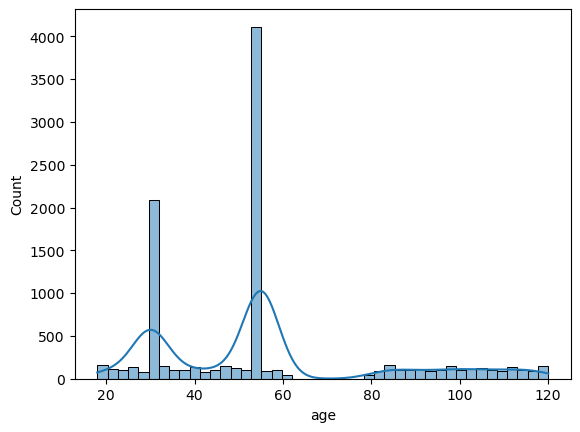

In [31]:
#  1   age                   7902 non-null   object   ----------> Numerical : Continous
sns.histplot(df['age'],kde=True)

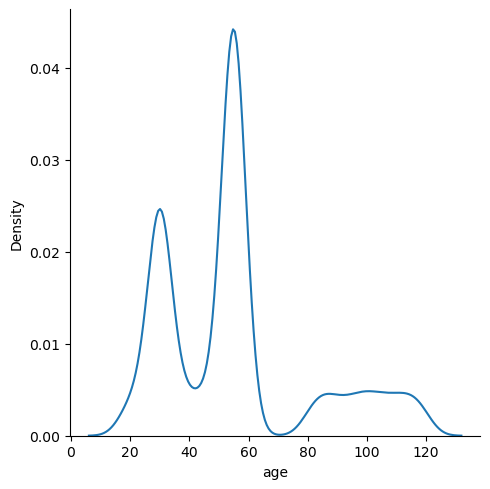

In [32]:
sns.displot(df['age'],kind='kde')

<Axes: ylabel='age'>

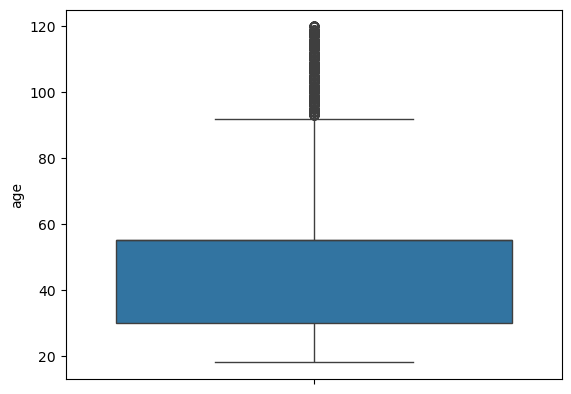

In [33]:
sns.boxplot(df['age'])

In [34]:
# after seeing all graphs, age data column is not a normal distribution. show i will do one more test to 
# confirm data age data column is normal or skew distributed
isAgeSkew = df['age'].skew()
print(isAgeSkew)
if -0.5 < isAgeSkew < 0.5:
    print("age column is a normally distributed")
else:
    print("age column is a skwed distributed")

0.9531290703350759
age column is a skwed distributed


In [35]:
#using tukeys method to remove outliers in age data column
statsAge = df['age'].describe()
ageIQR = statsAge['75%'] - statsAge['25%']

ageLB = statsAge['25%'] - 1.5*ageIQR
ageUB = statsAge['75%'] + 1.5*ageIQR
print(f"Age lower bond : {ageLB} and Age upper bond : {ageUB}")
df = df.loc[(df['age']>=ageLB) & (df['age']<=ageUB)]
df.reset_index(drop=True,inplace=True)
df.info()

Age lower bond : -7.5 and Age upper bond : 92.5
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8666 entries, 0 to 8665
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   emp_id                8666 non-null   object        
 1   age                   8666 non-null   int64         
 2   salary                8666 non-null   float64       
 3   department            8666 non-null   object        
 4   experience_years      8666 non-null   int64         
 5   last_promotion_year   8666 non-null   int32         
 6   performance_score     8666 non-null   float64       
 7   work_hours_per_week   8666 non-null   float64       
 8   remote_work_ratio     8666 non-null   int64         
 9   job_satisfaction      8666 non-null   float64       
 10  left_company          8666 non-null   object        
 11  joining_date          8666 non-null   datetime64[ns]
 12  bonus                 8666 n

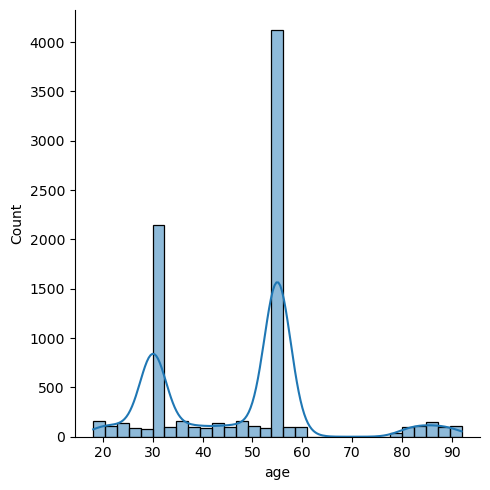

In [36]:
sns.displot(df['age'],kde=True)

<Axes: ylabel='age'>

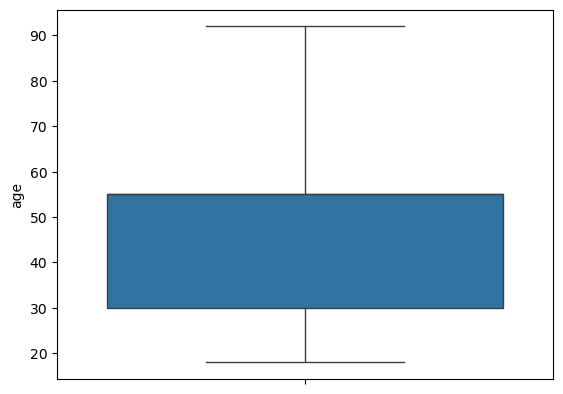

In [37]:
sns.boxplot(df['age'])

<Axes: xlabel='salary', ylabel='Count'>

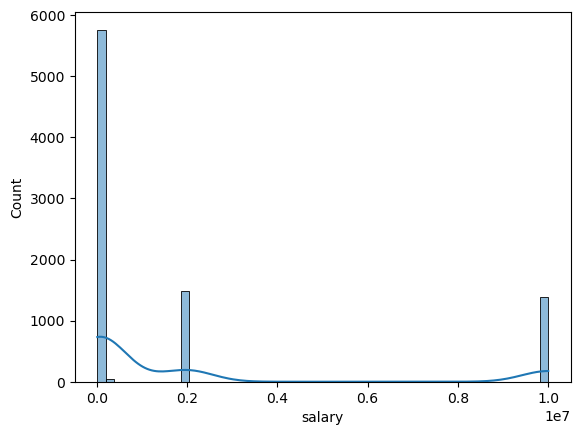

In [38]:
#  2   salary                10000 non-null  object   ----------> Numerical : Continous
sns.histplot(df['salary'],kde=True)

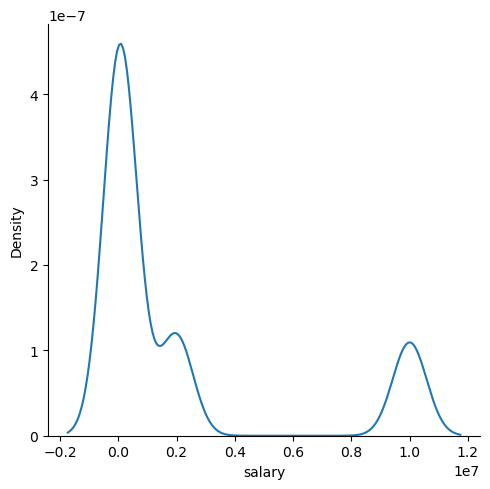

In [39]:
sns.displot(df['salary'],kind='kde')

<Axes: ylabel='salary'>

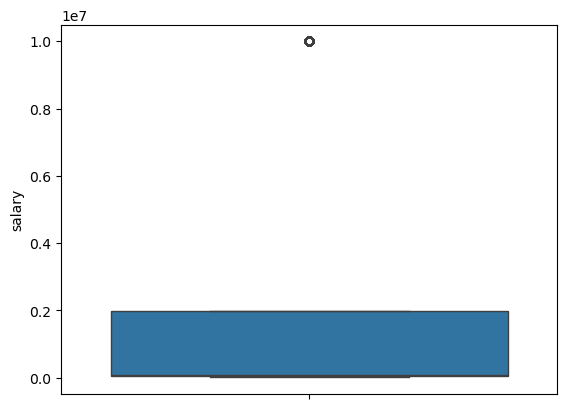

In [40]:
sns.boxplot(df['salary'])

In [41]:
# after seeing all graphs, salary data column is not a normal distribution. show i will do one more test to 
# confirm data salary data column is normal or skew distributed
isSalarySkew = df['salary'].skew()
print(isSalarySkew)
if -0.5 < isSalarySkew < 0.5:
    print("salary column is a normally distributed")
else:
    print("salary column is a skwed distributed")

1.7165338363453673
salary column is a skwed distributed


In [42]:
salQ1 = df['salary'].quantile(0.25)
salQ3 = df['salary'].quantile(0.75)
salIQR = salQ3 - salQ1

salLB = salQ1 - 1.5 * salIQR
salUB = salQ3 + 1.5 * salIQR

print(f"Salary lower bound: {salLB}, upper bound: {salUB}")

df = df[(df['salary'] >= salLB) & (df['salary'] <= salUB)]

df.reset_index(drop=True, inplace=True)
df.info()

Salary lower bound: -2845758.48354071, upper bound: 4886004.805901184
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7287 entries, 0 to 7286
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   emp_id                7287 non-null   object        
 1   age                   7287 non-null   int64         
 2   salary                7287 non-null   float64       
 3   department            7287 non-null   object        
 4   experience_years      7287 non-null   int64         
 5   last_promotion_year   7287 non-null   int32         
 6   performance_score     7287 non-null   float64       
 7   work_hours_per_week   7287 non-null   float64       
 8   remote_work_ratio     7287 non-null   int64         
 9   job_satisfaction      7287 non-null   float64       
 10  left_company          7287 non-null   object        
 11  joining_date          7287 non-null   datetime64[ns]
 12  bonus 

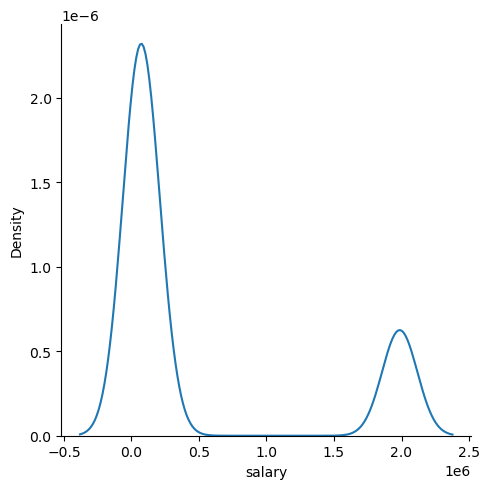

In [43]:
sns.displot(df['salary'],kind="kde")

<Axes: ylabel='salary'>

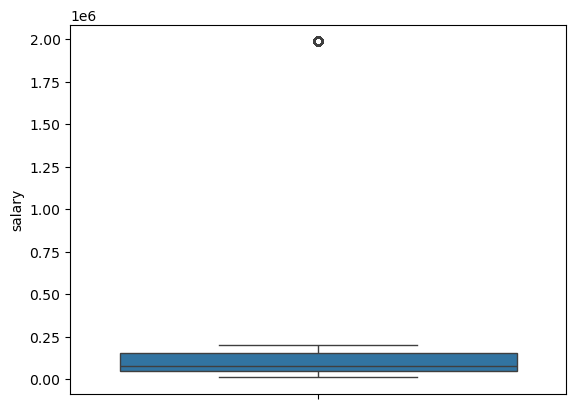

In [44]:
sns.boxplot(df['salary'])

<Axes: xlabel='experience_years', ylabel='Count'>

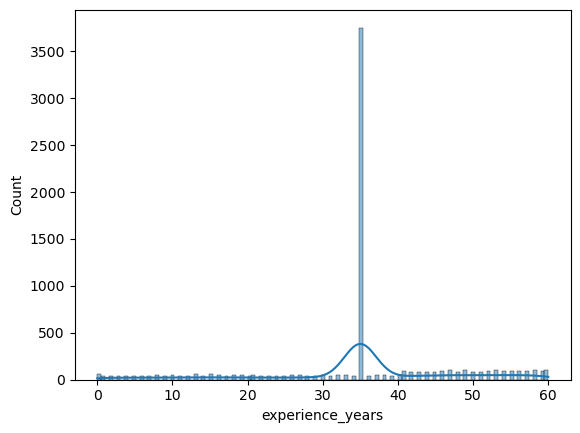

In [45]:
#  4   experience_years      7382 non-null   object   ----------> Numerical : Continous
sns.histplot(df['experience_years'],kde=True)

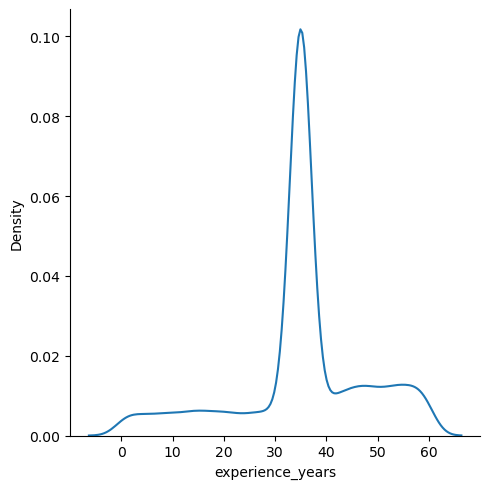

In [46]:
sns.displot(df['experience_years'],kind="kde")

<Axes: ylabel='experience_years'>

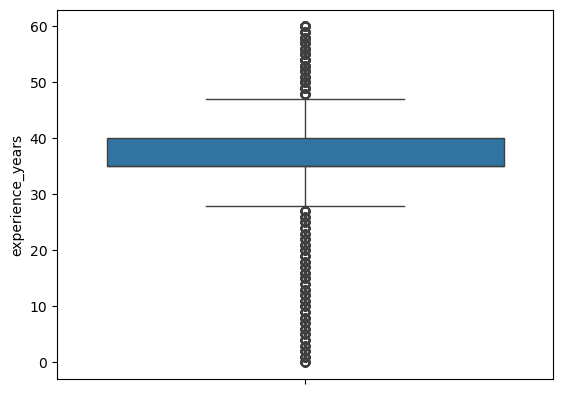

In [47]:
sns.boxplot(df['experience_years'])

In [48]:
# after seeing all graphs, experience_years data column is not a normal distribution. show i will do one more test to 
# confirm data experience_years data column is normal or skew distributed
isExpYearSkew = df['experience_years'].skew()
print(isExpYearSkew)
if -0.5 < isExpYearSkew < 0.5:
    print("experience_years column is a normally distributed")
else:
    print("experience_years column is a skwed distributed")

-0.5642467212385976
experience_years column is a skwed distributed


In [49]:
expYQ1 = df['experience_years'].quantile(0.25)
expYQ3 = df['experience_years'].quantile(0.75)
expYIQR = expYQ3 - expYQ1
expYLB = expYQ1 - 1.5*expYIQR
expYUB = expYQ3+1.5*expYIQR
print(f"experience_years lower bond : {expYLB} and experience_years upper bond : {expYUB}")

df = df.loc[(df['experience_years']>=expYLB) & (df['experience_years']<=expYUB)]

experience_years lower bond : 27.5 and experience_years upper bond : 47.5


<Axes: xlabel='performance_score', ylabel='Count'>

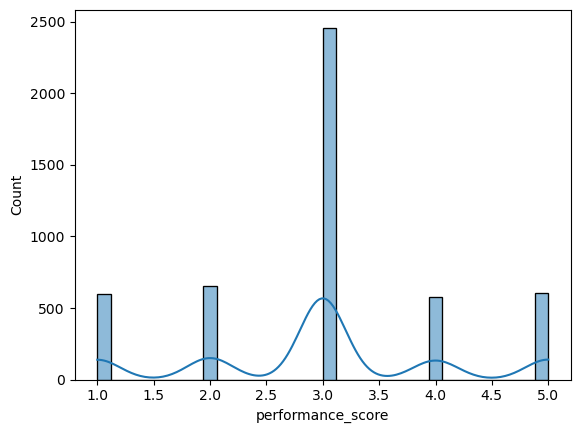

In [50]:
#  6   performance_score     6245 non-null   float64  ----------> Numerical : Discrete

sns.histplot(df['performance_score'],kde=True)

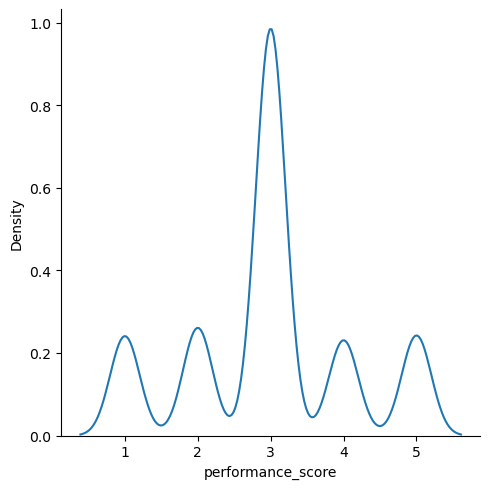

In [51]:
sns.displot(df['performance_score'],kind="kde")

<Axes: ylabel='performance_score'>

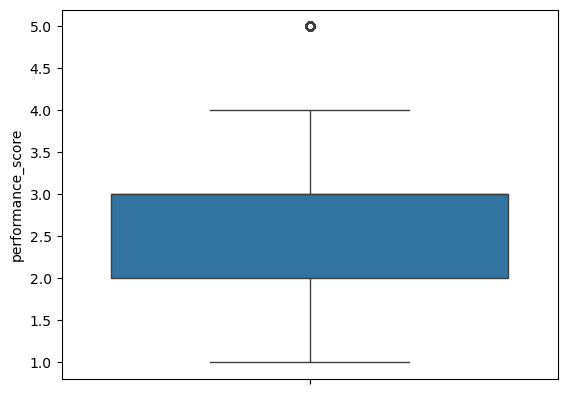

In [52]:
sns.boxplot(df['performance_score'])

In [53]:
# after seeing all graphs, performance_score data column is not a normal distribution. show i will do one more test to 
# confirm data performance_score data column is normal or skew distributed
isPerfScoreSkew = df['performance_score'].skew()
print(isPerfScoreSkew)
if -0.5 < isPerfScoreSkew < 0.5:
    print("performance_score column is a normally distributed")
else:
    print("performance_score column is a skwed distributed")

0.030566632663071806
performance_score column is a normally distributed


In [54]:
# we will use z-score for performance score data columns because it is a normal distribution
df['performance_z_score'] = stats.zscore(df['performance_score'])
df = df.loc[(df['performance_z_score']>= -3) & (df['performance_z_score']<= 3)]
df.drop('performance_z_score',axis=1,inplace=True)

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4892 entries, 1 to 7286
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   emp_id                4892 non-null   object        
 1   age                   4892 non-null   int64         
 2   salary                4892 non-null   float64       
 3   department            4892 non-null   object        
 4   experience_years      4892 non-null   int64         
 5   last_promotion_year   4892 non-null   int32         
 6   performance_score     4892 non-null   float64       
 7   work_hours_per_week   4892 non-null   float64       
 8   remote_work_ratio     4892 non-null   int64         
 9   job_satisfaction      4892 non-null   float64       
 10  left_company          4892 non-null   object        
 11  joining_date          4892 non-null   datetime64[ns]
 12  bonus                 4892 non-null   float64       
 13  manager_rating        4

<Axes: xlabel='bonus', ylabel='Count'>

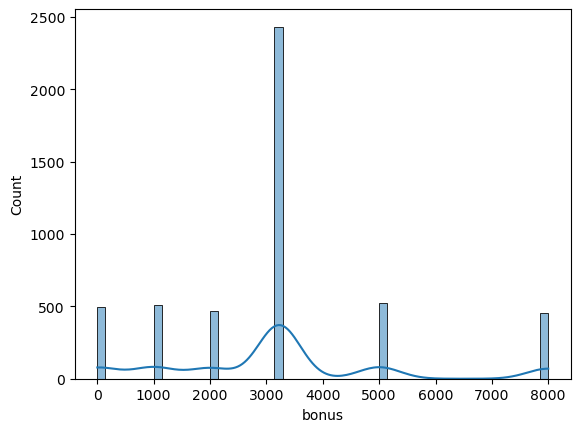

In [56]:
#  12  bonus                 5106 non-null   float64  ----------> Numerical : Continous
sns.histplot(df['bonus'],kde=True)

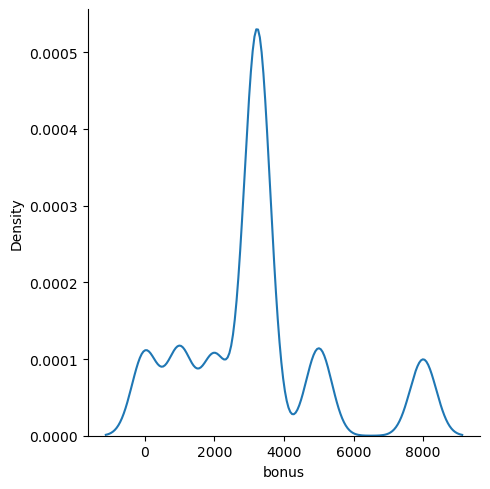

In [57]:
sns.displot(df['bonus'],kind='kde')

<Axes: ylabel='bonus'>

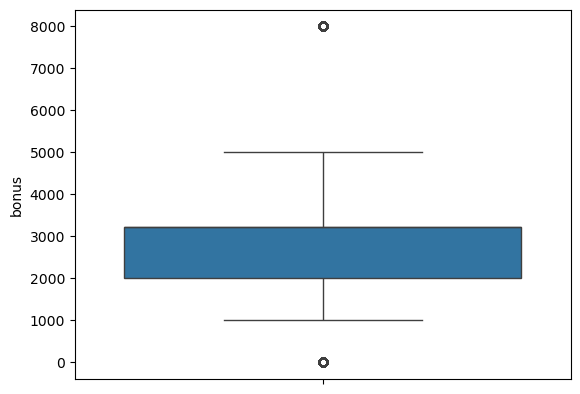

In [58]:
sns.boxplot(df['bonus'])

In [59]:
# after seeing all graphs, bonus data column is not a normal distribution. show i will do one more test to 
# confirm data bonus data column is normal or skew distributed
isbonusSkew = df['bonus'].skew()
print(isbonusSkew)
if -0.5 < isbonusSkew < 0.5:
    print("bonus column is a normally distributed")
else:
    print("bonus column is a skwed distributed")

0.7659950954848714
bonus column is a skwed distributed


In [60]:
bonusQ1 = df['bonus'].quantile(0.25)
bonusQ3 = df['bonus'].quantile(0.75)
bonusIQR = bonusQ3 - bonusQ1
bonusLB = bonusQ1 - 1.5*bonusIQR
bonusUB = bonusQ3 + 1.5*bonusIQR
print(f"Bonus lower bound : {bonusLB} and Bouns upper bound : {bonusUB}")
df = df[(df['bonus']>=bonusLB) & (df['bonus']<=bonusUB)]


Bonus lower bound : 158.9306698002349 and Bouns upper bound : 5068.448883666275


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3939 entries, 1 to 7284
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   emp_id                3939 non-null   object        
 1   age                   3939 non-null   int64         
 2   salary                3939 non-null   float64       
 3   department            3939 non-null   object        
 4   experience_years      3939 non-null   int64         
 5   last_promotion_year   3939 non-null   int32         
 6   performance_score     3939 non-null   float64       
 7   work_hours_per_week   3939 non-null   float64       
 8   remote_work_ratio     3939 non-null   int64         
 9   job_satisfaction      3939 non-null   float64       
 10  left_company          3939 non-null   object        
 11  joining_date          3939 non-null   datetime64[ns]
 12  bonus                 3939 non-null   float64       
 13  manager_rating        3

# Data visualization and Bussiness Insites

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3939 entries, 1 to 7284
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   emp_id                3939 non-null   object        
 1   age                   3939 non-null   int64         
 2   salary                3939 non-null   float64       
 3   department            3939 non-null   object        
 4   experience_years      3939 non-null   int64         
 5   last_promotion_year   3939 non-null   int32         
 6   performance_score     3939 non-null   float64       
 7   work_hours_per_week   3939 non-null   float64       
 8   remote_work_ratio     3939 non-null   int64         
 9   job_satisfaction      3939 non-null   float64       
 10  left_company          3939 non-null   object        
 11  joining_date          3939 non-null   datetime64[ns]
 12  bonus                 3939 non-null   float64       
 13  manager_rating        3

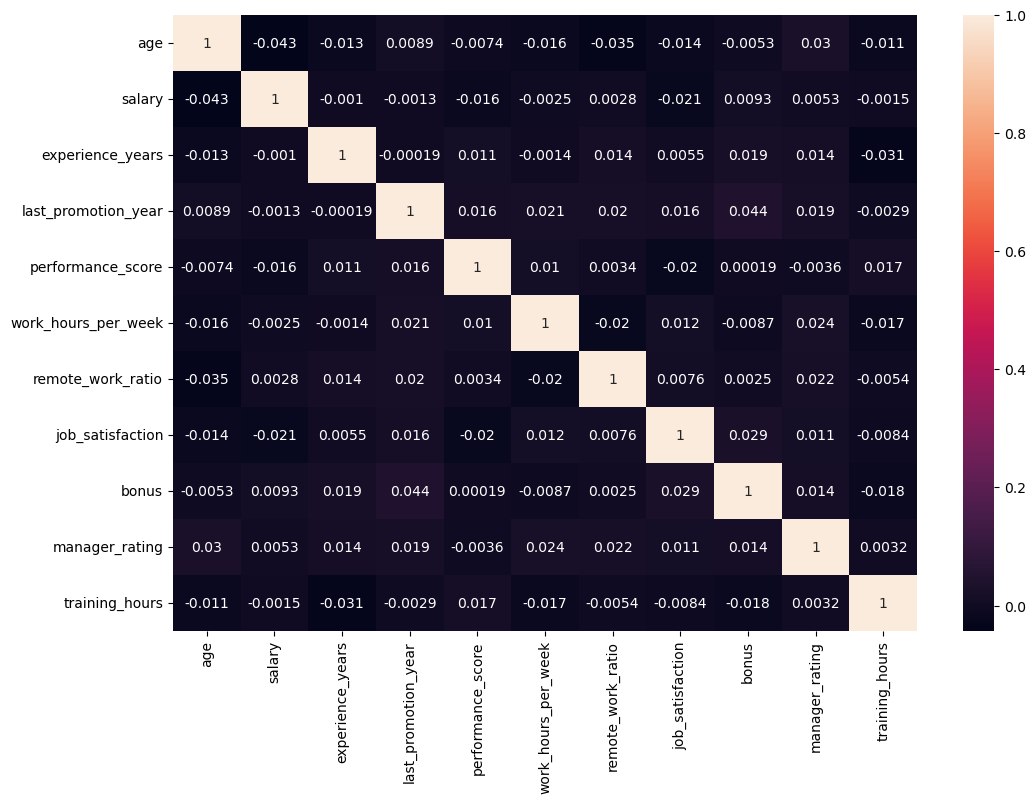

In [63]:
plt.figure(figsize=(12, 8))  # 🔥 increase size
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [64]:
# Numerical visulazitation

<Axes: xlabel='salary', ylabel='age'>

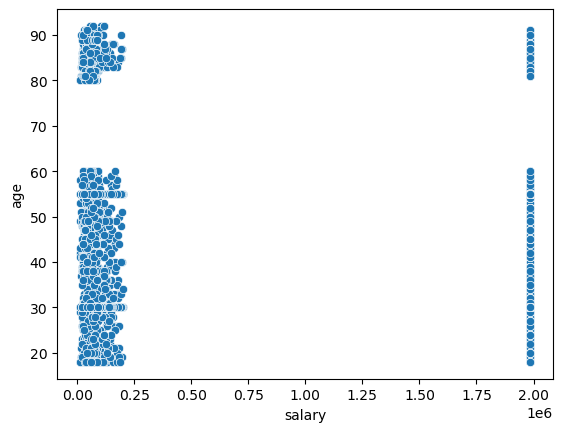

In [65]:
# age and salary
sns.scatterplot(data=df,x='salary',y='age')

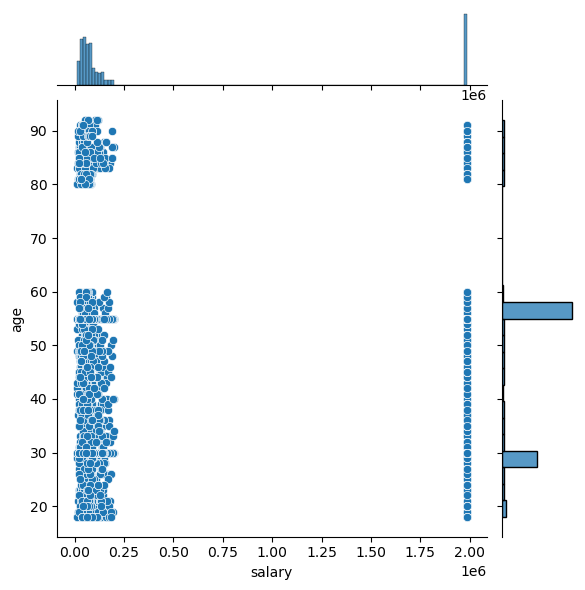

In [66]:
sns.jointplot(data=df,x='salary',y='age')

<Axes: >

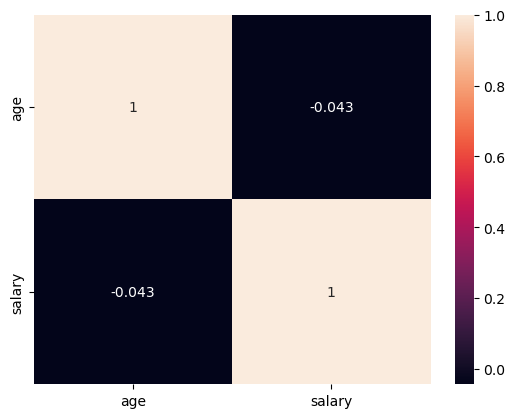

In [67]:
ageSalaryCorr = df[['age', 'salary']].corr()
sns.heatmap(ageSalaryCorr,annot=True)

In [68]:
# After seeing all graphs of age and salary columns. I conclude that scatter plot is likly to cluster distribution. 
# Age and Salary didn't have any correlation 

<Axes: xlabel='age', ylabel='experience_years'>

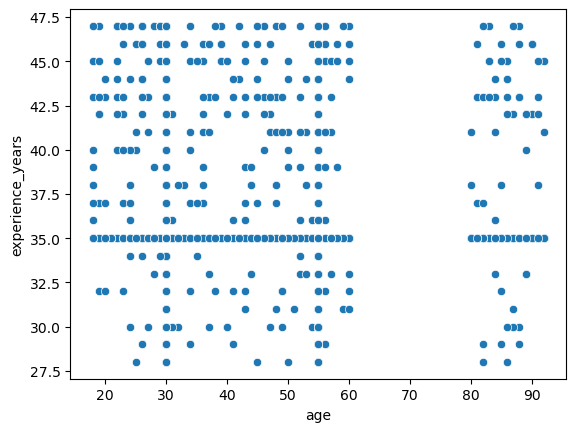

In [69]:
# age and experience_years
sns.scatterplot(data=df,x="age",y="experience_years")

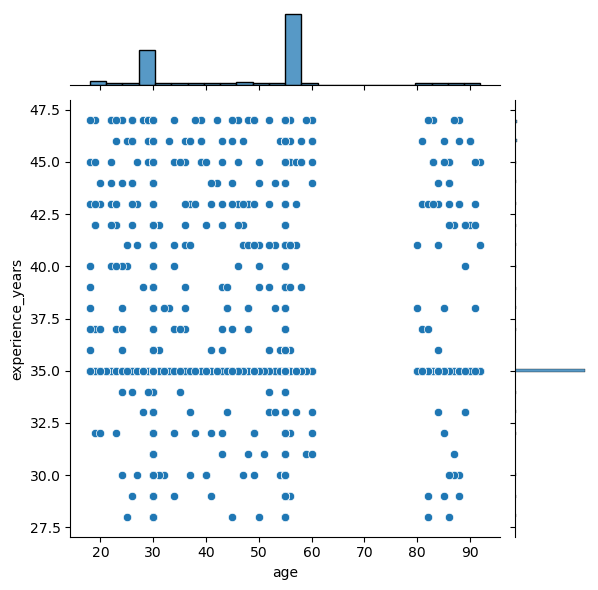

In [70]:
sns.jointplot(data=df,x="age",y="experience_years")

<Axes: >

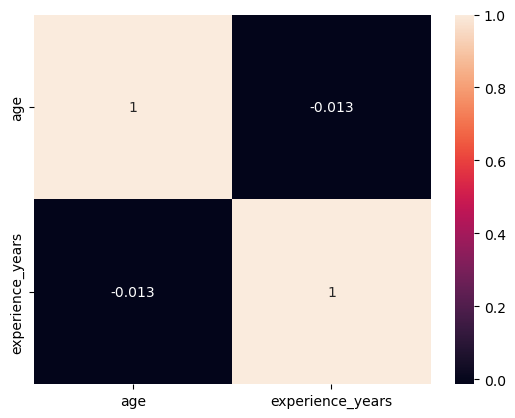

In [71]:
ageExpCorr = df[['age','experience_years']].corr()
sns.heatmap(ageExpCorr,annot=True)

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3939 entries, 1 to 7284
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   emp_id                3939 non-null   object        
 1   age                   3939 non-null   int64         
 2   salary                3939 non-null   float64       
 3   department            3939 non-null   object        
 4   experience_years      3939 non-null   int64         
 5   last_promotion_year   3939 non-null   int32         
 6   performance_score     3939 non-null   float64       
 7   work_hours_per_week   3939 non-null   float64       
 8   remote_work_ratio     3939 non-null   int64         
 9   job_satisfaction      3939 non-null   float64       
 10  left_company          3939 non-null   object        
 11  joining_date          3939 non-null   datetime64[ns]
 12  bonus                 3939 non-null   float64       
 13  manager_rating        3

In [73]:
totalSalaryByDept = df.groupby('department')['salary'].sum()
totalSalaryByCity = df.groupby('city')['salary'].sum()
totalExpByDept = df.groupby('department')['experience_years'].sum()
totalExpByCity = df.groupby('city')['experience_years'].sum()
totalBonusByDept = df.groupby('department')['bonus'].sum()
print(f"\nTotal Salary by department : {totalSalaryByDept}")
print(f"\nTotal Salary by city : {totalSalaryByCity}")
print(f"\nTotal exprience by department : {totalExpByDept}")
print(f"\nTotal exprience by city : {totalExpByCity}")
print(f"\nTotal bonus by department : {totalBonusByDept}")


Total Salary by department : department
Finance       3.683400e+08
Hr            3.653247e+08
It            7.382861e+08
Operations    1.797549e+08
Sales         1.872022e+08
Name: salary, dtype: float64

Total Salary by city : city
Bangalore    2.447666e+08
Chennai      2.612809e+08
Delhi        5.366135e+08
Kolkata      2.708286e+08
Mumbai       2.502528e+08
Pune         2.751655e+08
Name: salary, dtype: float64

Total exprience by department : department
Finance       28732
Hr            28707
It            57164
Operations    12981
Sales         14325
Name: experience_years, dtype: int64

Total exprience by city : city
Bangalore    20676
Chennai      19860
Delhi        40872
Kolkata      19949
Mumbai       20031
Pune         20521
Name: experience_years, dtype: int64

Total bonus by department : department
Finance       2.442599e+06
Hr            2.414961e+06
It            4.771922e+06
Operations    1.097160e+06
Sales         1.194571e+06
Name: bonus, dtype: float64


# Hypothesis Testing 
1. Normality Test
2. Correlation Test
3. Parametric Test
4. Non-parametric Test
5. Test for feature elimination
6. Categorical Test

In [75]:
# 1. Normality Test for bonus , age , salary
# shapiro test
SL = 0.05
from scipy.stats import shapiro

# calc p-value
stats , pvalue = shapiro(df['bonus'])

if pvalue >= SL:
    print("Alt Hypothesis (ha) ---> bonus is Normally Distributed.")
else:
    print("Null Hypothesis(h0) ---> bonus is NOT normally distributed.")


Null Hypothesis(h0) ---> bonus is NOT normally distributed.


In [77]:
# calc p-value
stats , pvalue = shapiro(df['age'])

if pvalue >= SL:
    print("Alt Hypothesis (ha) ---> age is Normally Distributed.")
else:
    print("Null Hypothesis(h0) ---> age is NOT normally distributed.")

Null Hypothesis(h0) ---> age is NOT normally distributed.


In [78]:
# calc p-value
stats , pvalue = shapiro(df['salary'])

if pvalue >= SL:
    print("Alt Hypothesis (ha) ---> salary is Normally Distributed.")
else:
    print("Null Hypothesis(h0) ---> salary is NOT normally distributed.")

Null Hypothesis(h0) ---> salary is NOT normally distributed.


In [80]:
# correlation test age , salary , bonus

from scipy.stats import pearsonr

# Calc pvalue

corr, pvalue = pearsonr(df["age"], df["salary"])

# Compare pvaluue with SL

if pvalue <= SL:
    print("Alt Hypothesis (ha) ----> age and salary has linear relationship")
else:
    print("Null Hypothesis (H0) ---> age and salary has NO linear relationship")

Alt Hypothesis (ha) ----> age and salary has linear relationship


In [79]:
from scipy.stats import pearsonr

# Calc pvalue

corr, pvalue = pearsonr(df["age"], df["bonus"])

# Compare pvaluue with SL

if pvalue <= SL:
    print("Alt Hypothesis (ha) ----> age and bonus has linear relationship")
else:
    print("Null Hypothesis (H0) ---> age and bonus has NO linear relationship")

Null Hypothesis (H0) ---> age and bonus has NO linear relationship


In [ ]:
# Parametric Test age , salary , bonus

